In [1]:
# ============================================
# CELLULE 1 — Imports + Chargement données
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Charger le dataset
df = pd.read_csv('../data/diabetes.csv')

print("✅ Dataset chargé !")
print(f"📐 Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé !
📐 Dimensions : 768 lignes x 9 colonnes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# ============================================
# CELLULE 2 — Exploration des données
# ============================================
print("=" * 50)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("📊 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
print(df.describe().round(2))

print("\n" + "=" * 50)
print("⚠️  VALEURS ZÉRO IMPOSSIBLES")
print("=" * 50)
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    zeros = (df[col] == 0).sum()
    print(f"   {col:25} : {zeros} zéros ({zeros/len(df)*100:.1f}%)")

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

📊 STATISTIQUES DESCRIPTIVES
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.1

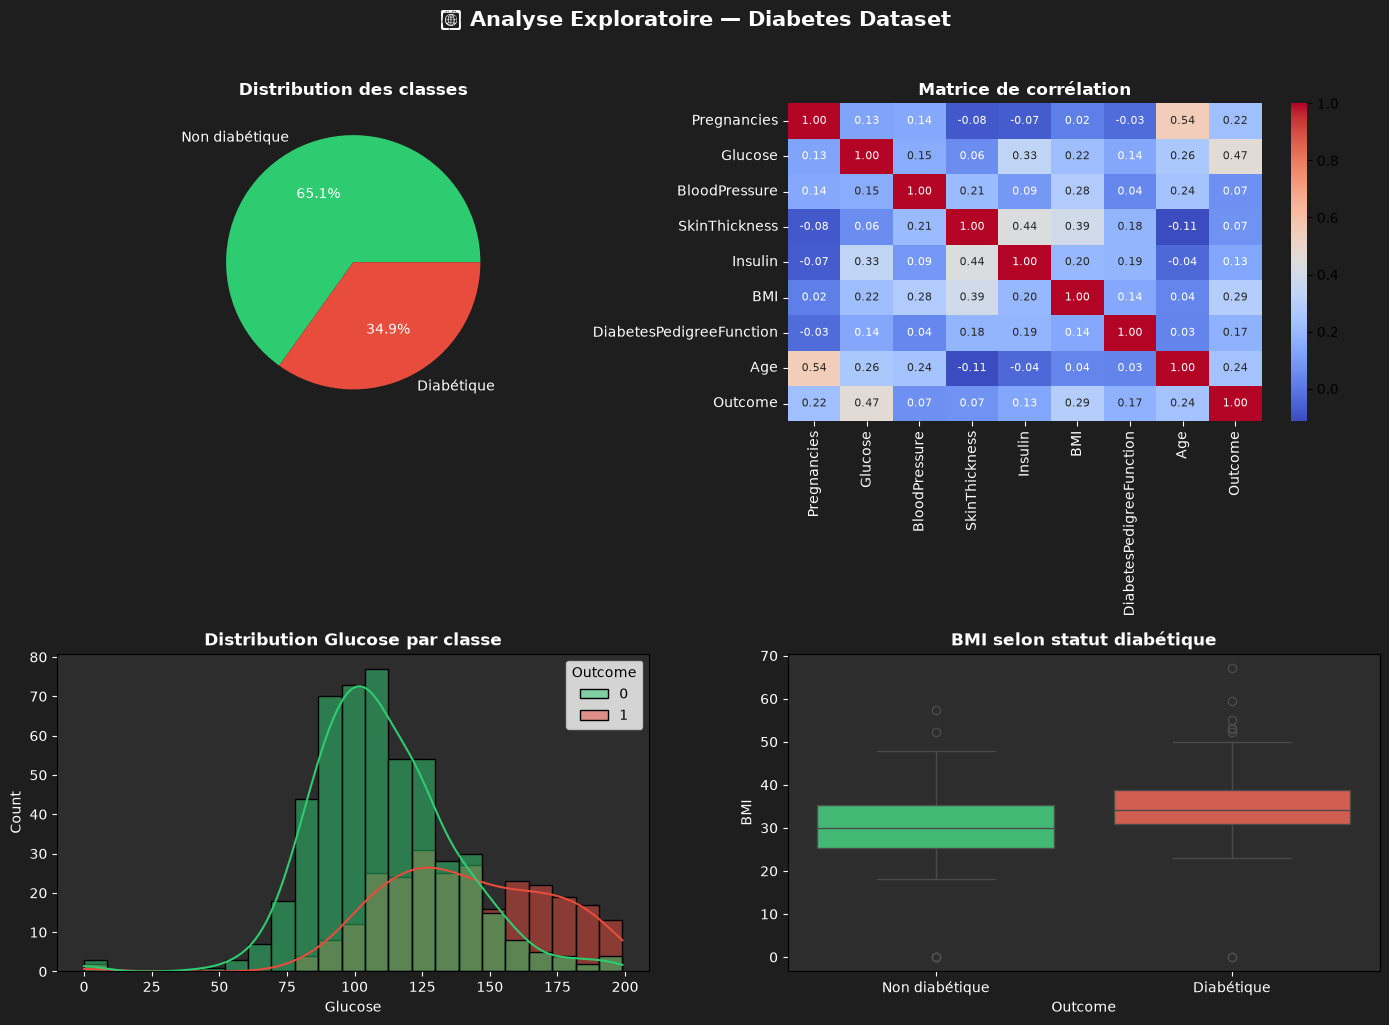

✅ Graphiques sauvegardés dans app/eda_plots.png


In [3]:
# ============================================
# CELLULE 3 — Visualisations EDA
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#1e1e1e')
for ax in axes.flat:
    ax.set_facecolor('#2d2d2d')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# 1. Pie chart
axes[0,0].pie(df['Outcome'].value_counts(),
              labels=['Non diabétique', 'Diabétique'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
              textprops={'color':'white'})
axes[0,0].set_title('Distribution des classes', fontweight='bold')

# 2. Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0,1], annot_kws={'size':8})
axes[0,1].set_title('Matrice de corrélation', fontweight='bold')

# 3. Glucose distribution
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True,
             palette={0:'#2ecc71', 1:'#e74c3c'}, ax=axes[1,0])
axes[1,0].set_title('Distribution Glucose par classe', fontweight='bold')

# 4. Boxplot BMI
sns.boxplot(data=df, x='Outcome', y='BMI', hue='Outcome',
            palette=['#2ecc71','#e74c3c'], legend=False, ax=axes[1,1])
axes[1,1].set_title('BMI selon statut diabétique', fontweight='bold')
axes[1,1].set_xticks([0,1])
axes[1,1].set_xticklabels(['Non diabétique','Diabétique'])

plt.suptitle('🔍 Analyse Exploratoire — Diabetes Dataset',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('../app/eda_plots.png', dpi=150, bbox_inches='tight',
            facecolor='#1e1e1e')
plt.show()
print("✅ Graphiques sauvegardés dans app/eda_plots.png")

In [4]:
# ============================================
# CELLULE 4 — Nettoyage + Feature Engineering
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Remplacer zéros impossibles par médiane
cols_zeros = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_clean = df.copy()
for col in cols_zeros:
    mediane = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, mediane)
print("✅ Zéros remplacés par médiane")

# 2. Feature Engineering
df_clean['Obese']       = (df_clean['BMI'] > 30).astype(int)
df_clean['HighGlucose'] = (df_clean['Glucose'] > 125).astype(int)
df_clean['AgeGroup']    = pd.cut(df_clean['Age'],
                           bins=[0,30,45,100],
                           labels=[0,1,2]).astype(int)
print("✅ 3 nouvelles features créées : Obese, HighGlucose, AgeGroup")

# 3. Split
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print("✅ Données normalisées et prêtes !")

✅ Zéros remplacés par médiane
✅ 3 nouvelles features créées : Obese, HighGlucose, AgeGroup
✅ Train : 614 lignes | Test : 154 lignes
✅ Données normalisées et prêtes !


In [5]:
# ============================================
# CELLULE 5 — Entraînement des 4 modèles
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modeles = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42, probability=True),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss'),
}

resultats = {}
predictions = {}

for nom, modele in modeles.items():
    modele.fit(X_train_scaled, y_train)
    y_pred = modele.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    resultats[nom] = acc
    predictions[nom] = y_pred
    print(f"{'✅'} {nom:<25} Accuracy: {acc*100:.2f}%")

print("\n" + "=" * 50)
print("🏆 CLASSEMENT FINAL")
print("=" * 50)
for i, (nom, acc) in enumerate(sorted(resultats.items(), 
                                key=lambda x: x[1], reverse=True), 1):
    medal = ['🥇','🥈','🥉','4️⃣'][i-1]
    print(f"{medal} {nom:<25} {acc*100:.2f}%")

meilleur = max(resultats, key=resultats.get)
print(f"\n🏆 Meilleur modèle : {meilleur} ({resultats[meilleur]*100:.2f}%)")

✅ Logistic Regression       Accuracy: 72.73%
✅ Random Forest             Accuracy: 72.73%
✅ SVM                       Accuracy: 75.97%
✅ XGBoost                   Accuracy: 73.38%

🏆 CLASSEMENT FINAL
🥇 SVM                       75.97%
🥈 XGBoost                   73.38%
🥉 Logistic Regression       72.73%
4️⃣ Random Forest             72.73%

🏆 Meilleur modèle : SVM (75.97%)


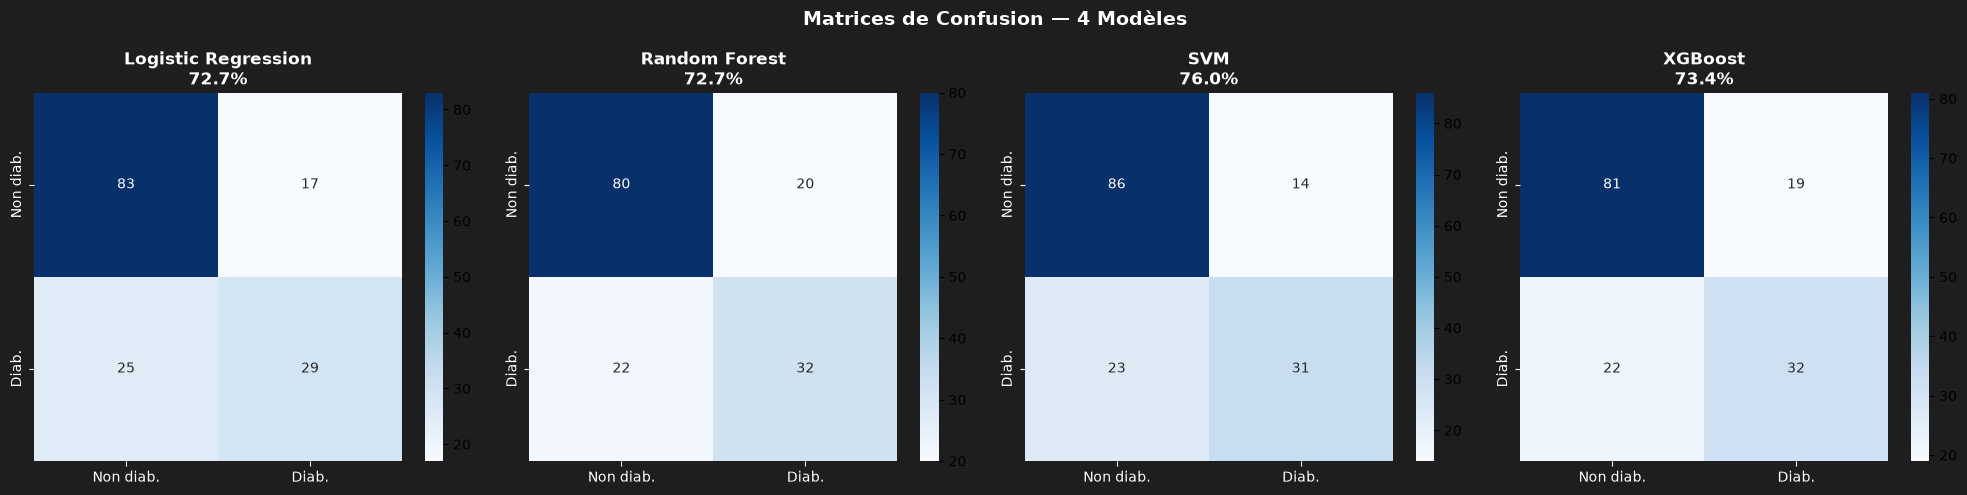

✅ Matrices sauvegardées dans app/
✅ Modèle SVM sauvegardé dans models/svm_model.pkl
✅ Scaler sauvegardé dans models/scaler.pkl


In [6]:
# ============================================
# CELLULE 6 — Matrices de confusion + Sauvegarde
# ============================================
import pickle

# 1. Matrices de confusion
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#1e1e1e')

for ax, (nom, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non diab.','Diab.'],
                yticklabels=['Non diab.','Diab.'])
    acc = resultats[nom]
    ax.set_title(f'{nom}\n{acc*100:.1f}%', fontweight='bold', color='white')
    ax.set_facecolor('#2d2d2d')
    ax.tick_params(colors='white')

plt.suptitle('Matrices de Confusion — 4 Modèles',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('../app/confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

# 2. Sauvegarde du meilleur modèle (SVM)
with open('../models/svm_model.pkl', 'wb') as f:
    pickle.dump(modeles['SVM'], f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Matrices sauvegardées dans app/")
print("✅ Modèle SVM sauvegardé dans models/svm_model.pkl")
print("✅ Scaler sauvegardé dans models/scaler.pkl")